# Clustering Candidates Analysis

In [1]:
import os, sys
import polars as pl

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    get_SampleDistClustering_results,
    get_KMeans_results
)

from config.config_07b import embeddings_cols_50, embeddings_cols_90

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [2]:
QUANT_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score'
]

CAT_COMPARISON_COLS = [
    'discourse_tone_score_label', 
    'dominant_frame_score_label', 
    'argument_quality_score_label', 
    'sentiment_score_label', 
    'political_stance_score_label'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

ASSOCIATION_VAR_TYPES = {
    'sentiment_score': 'continuous',
    'political_stance_score': 'ordinal' ,
    'argument_quality_score': 'ordinal', 
    'discourse_tone_score': 'nominal', 
    'dominant_frame_score': 'nominal', 
}

N_CLUSTERS_LIST = range(2,6)


## Clustering I: Data - Discursive Scores

In [3]:
numerical_cols = [
    'sentiment_score'
]

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols + ordinal_cols
binary_cols = []
multiclass_cols = nominal_cols

SampleDistClustering-KMedoids-PAM - k=4


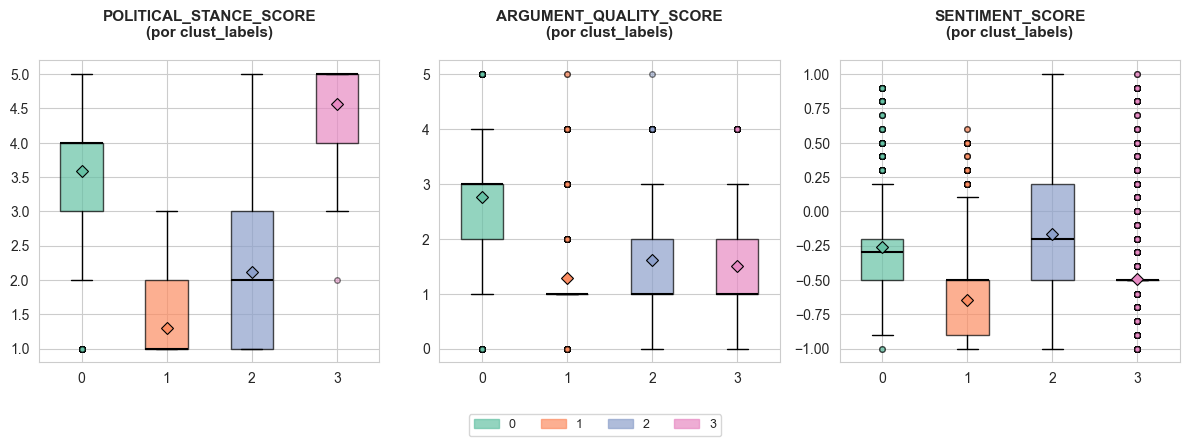

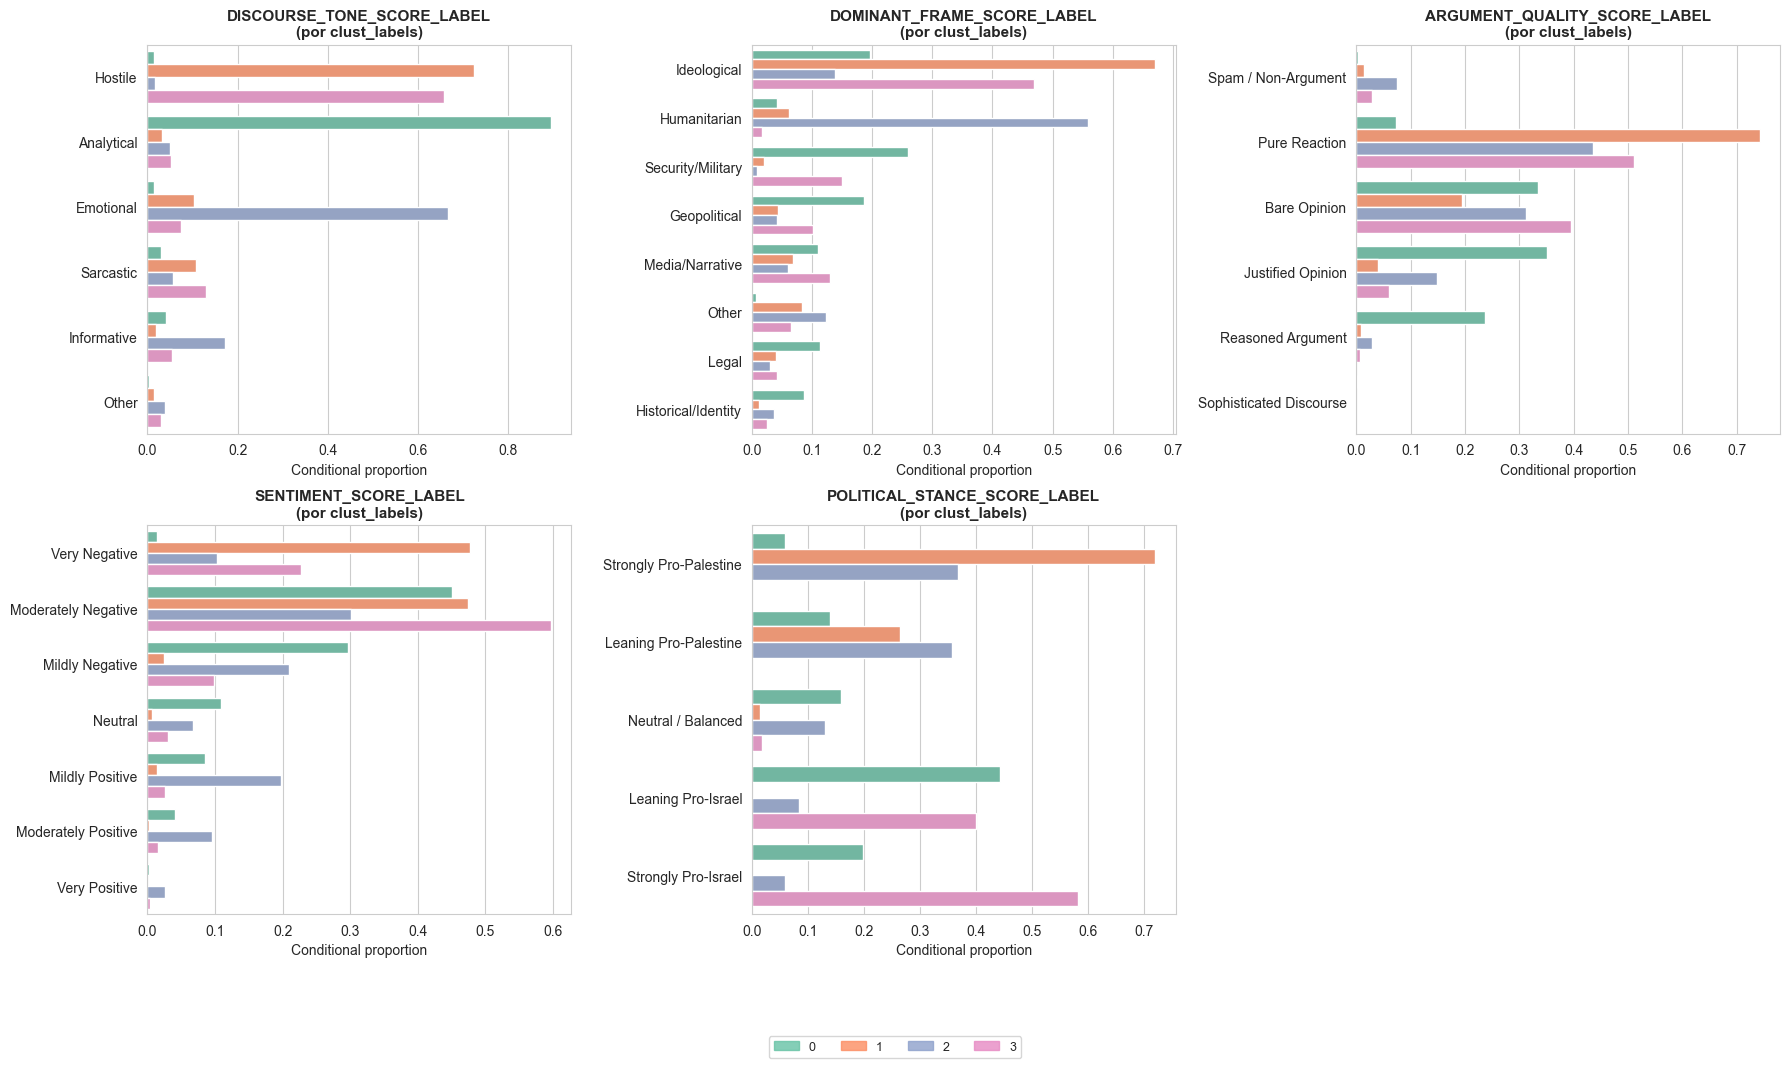

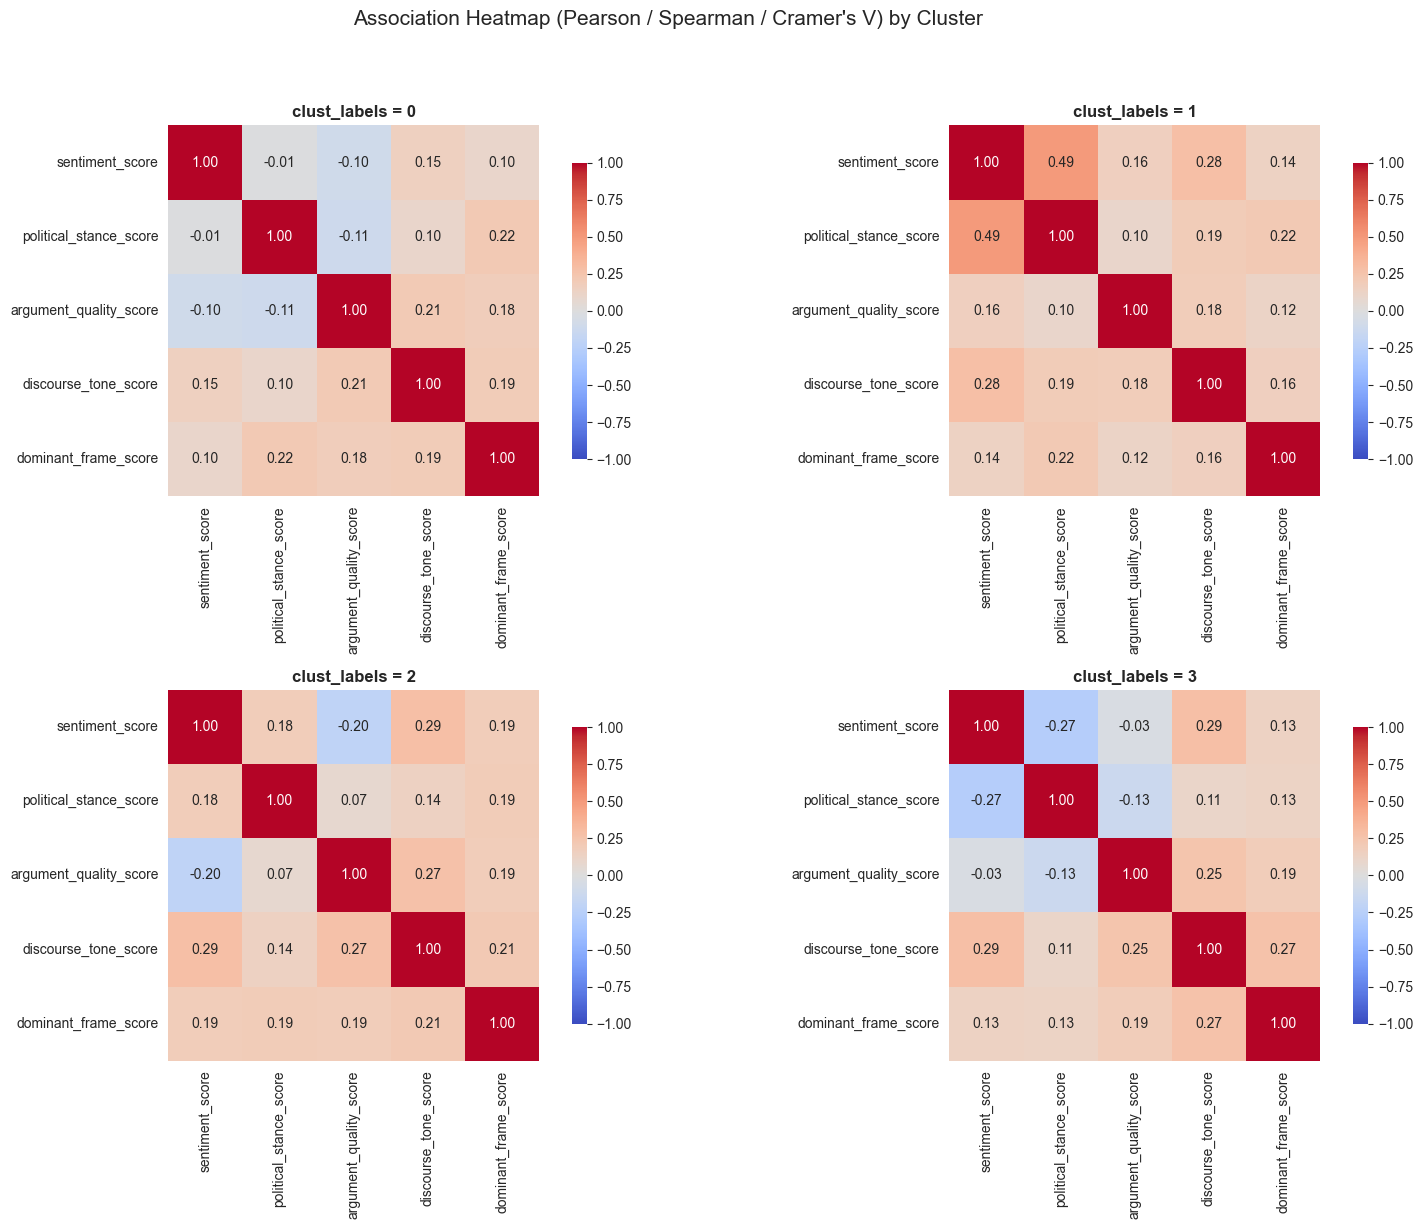

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------
shape: (11, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ post_title ┆ post_body  ┆ comment_bo ┆ discourse ┆ dominant_ ┆ argument_ ┆ sentiment ┆ political │
│ ---        ┆ ---        ┆ dy         ┆ _tone_sco ┆ frame_sco ┆ quality_s ┆ _score_la ┆ _stance_s │
│ str        ┆ str        ┆ ---        ┆ re_label  ┆ re_label  ┆ core_labe ┆ bel       ┆ core_labe │
│            ┆            ┆ str        ┆ ---       ┆ ---       ┆ l         ┆ ---       ┆ l         │
│            ┆            ┆            ┆ str       ┆ str       ┆ ---       ┆ str       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ str       ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Will       ┆ It is      ┆ Of course  ┆ Ana

In [4]:
for n_clusters in [4]: #N_CLUSTERS_LIST:

    get_SampleDistClustering_results(
        n_clusters, processed_data, quant_cols, binary_cols, multiclass_cols, 
        QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
)

# Time: 30 mins

## Clustering II: Data - Discursive Scores + Embeddings (PCA 50% explained variance)

In [5]:
numerical_cols = ['sentiment_score'] + embeddings_cols_50

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols
binary_cols = []
multiclass_cols = nominal_cols + ordinal_cols

SampleDistClustering-KMedoids-PAM - k=4


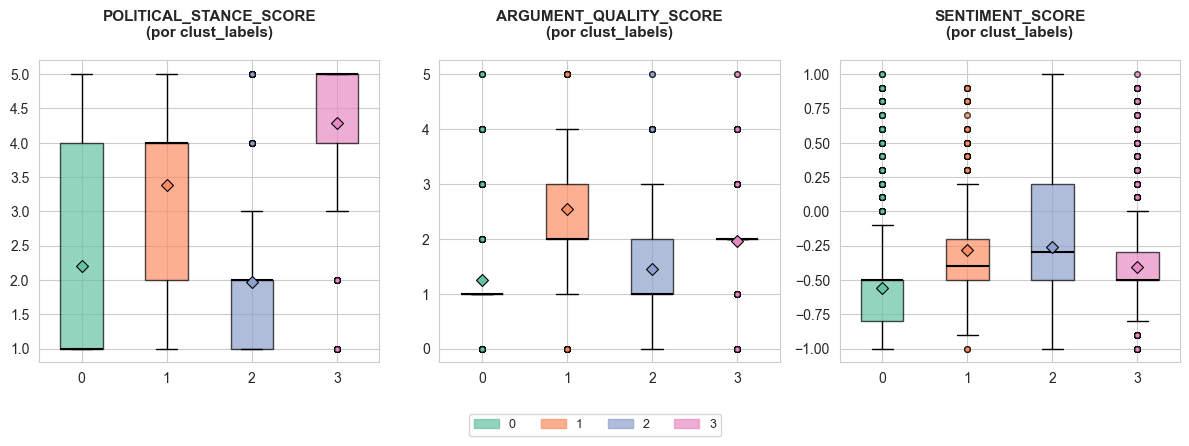

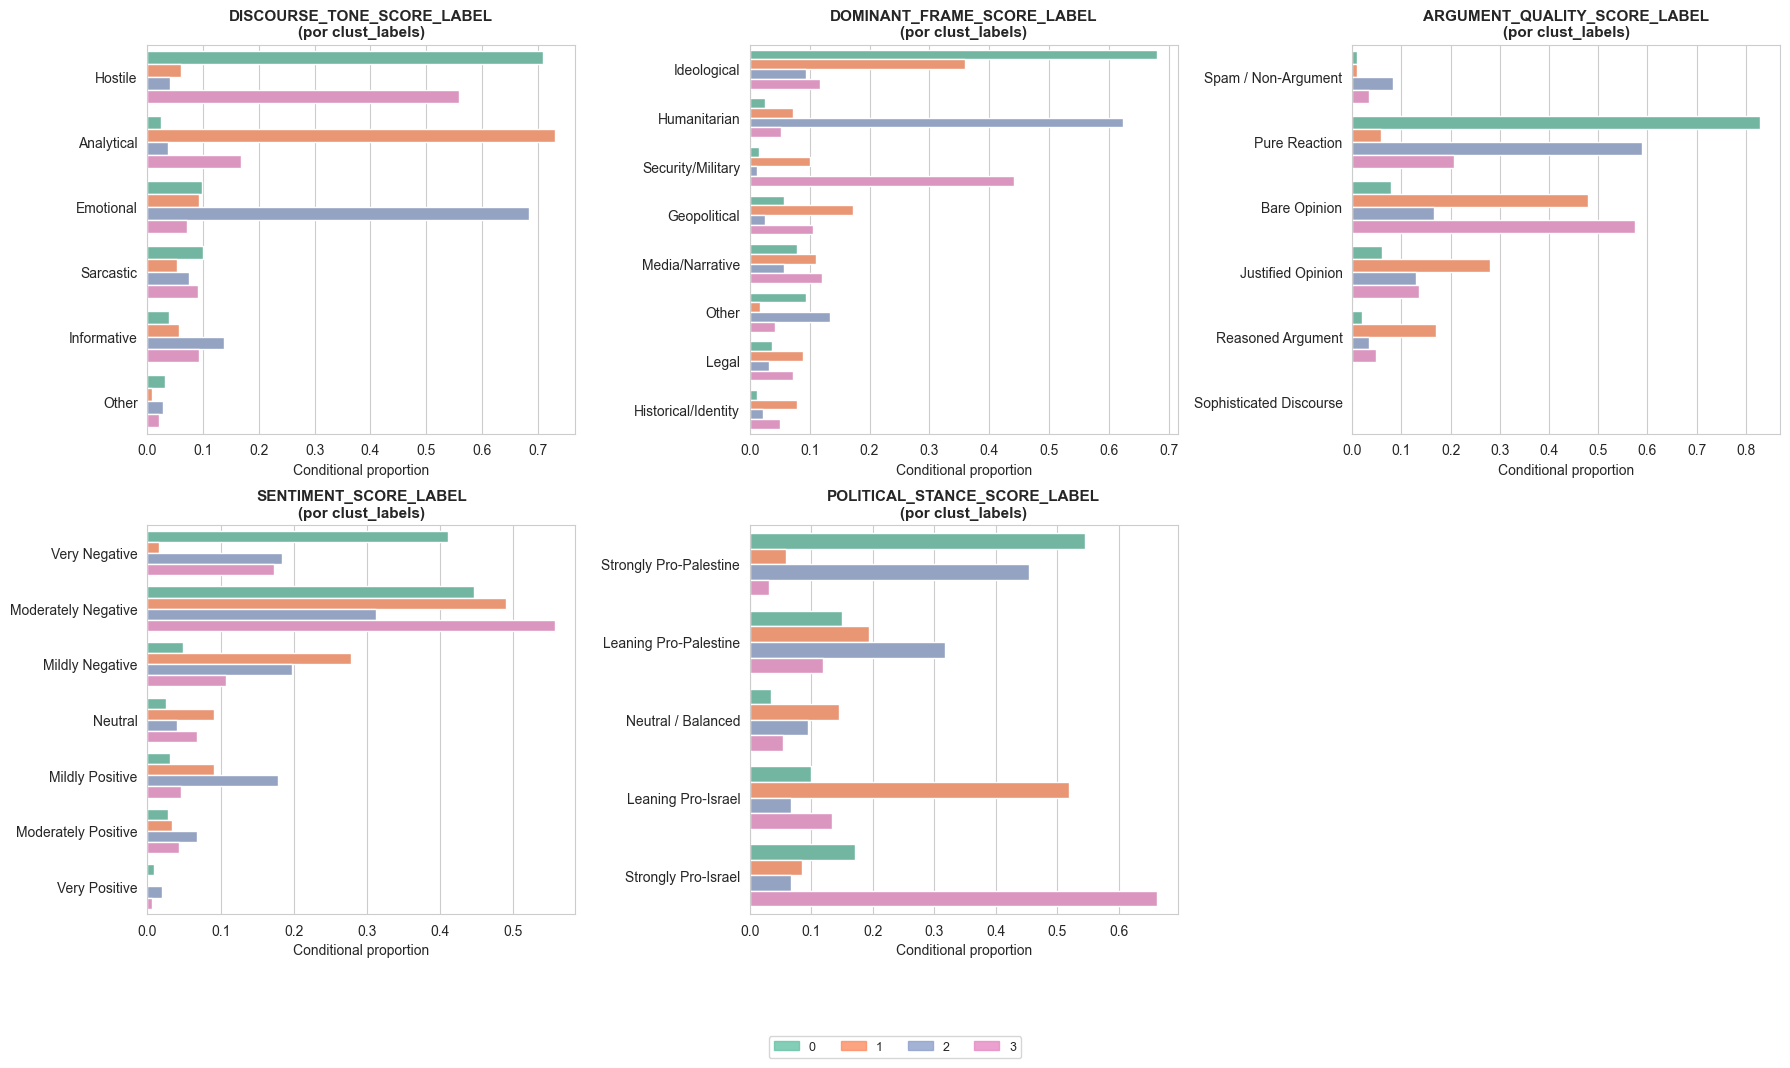

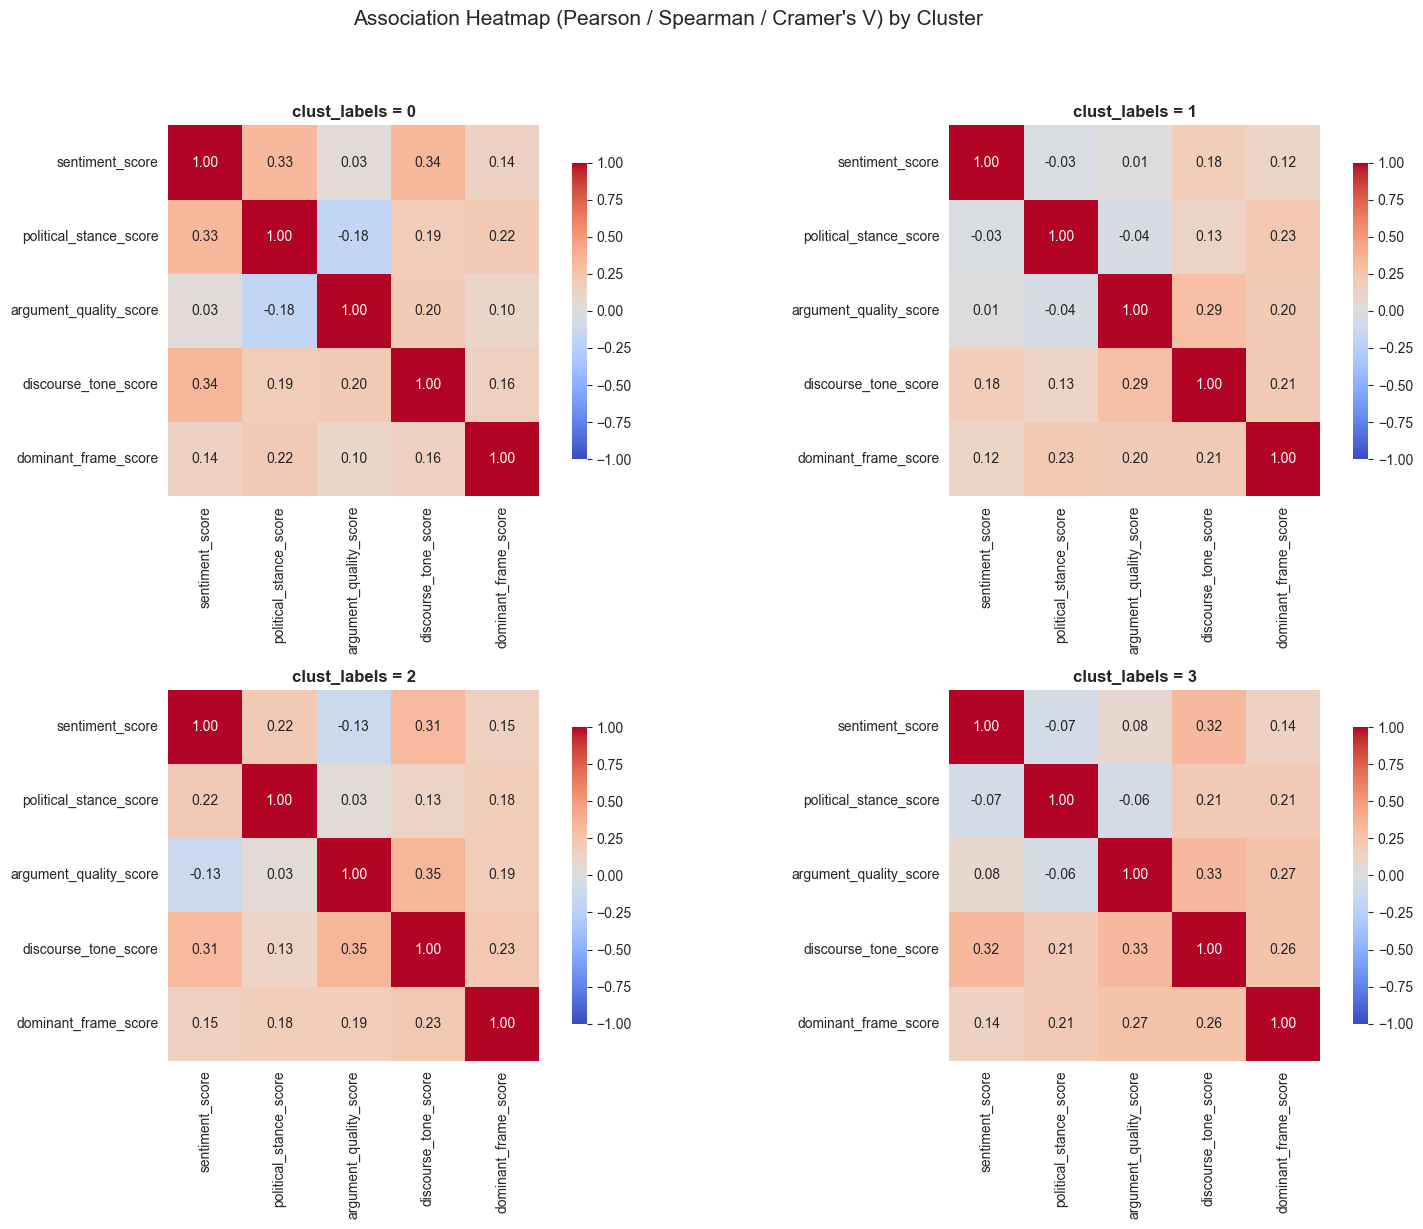

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------
shape: (11, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ post_title ┆ post_body  ┆ comment_bo ┆ discourse ┆ dominant_ ┆ argument_ ┆ sentiment ┆ political │
│ ---        ┆ ---        ┆ dy         ┆ _tone_sco ┆ frame_sco ┆ quality_s ┆ _score_la ┆ _stance_s │
│ str        ┆ str        ┆ ---        ┆ re_label  ┆ re_label  ┆ core_labe ┆ bel       ┆ core_labe │
│            ┆            ┆ str        ┆ ---       ┆ ---       ┆ l         ┆ ---       ┆ l         │
│            ┆            ┆            ┆ str       ┆ str       ┆ ---       ┆ str       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ str       ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ The Two    ┆ The posts  ┆ Nah.       ┆ Hos

In [6]:
for n_clusters in [4]: #N_CLUSTERS_LIST:

    get_SampleDistClustering_results(
        n_clusters, processed_data, quant_cols, binary_cols, multiclass_cols, 
        QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
    )

# Time: 60 mins

## Clustering II-b: Data - Discursive Scores + Embeddings (PCA 90% explained variance)

In [ ]:
numerical_cols = ['sentiment_score'] + embeddings_cols_90

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols
binary_cols = []
multiclass_cols = nominal_cols + ordinal_cols

In [ ]:
for n_clusters in [4]: #N_CLUSTERS_LIST:

    get_SampleDistClustering_results(
        n_clusters, processed_data, quant_cols, binary_cols, multiclass_cols, 
        QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
    )

# Time: 60 mins

## Clustering III: Data - Embeddings (PCA 50% explained variance)

KMeans - k=4


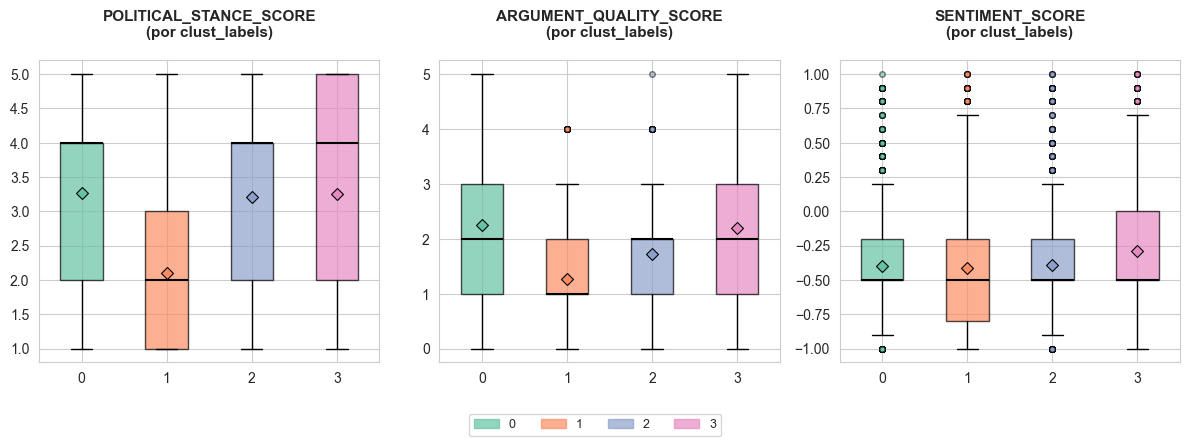

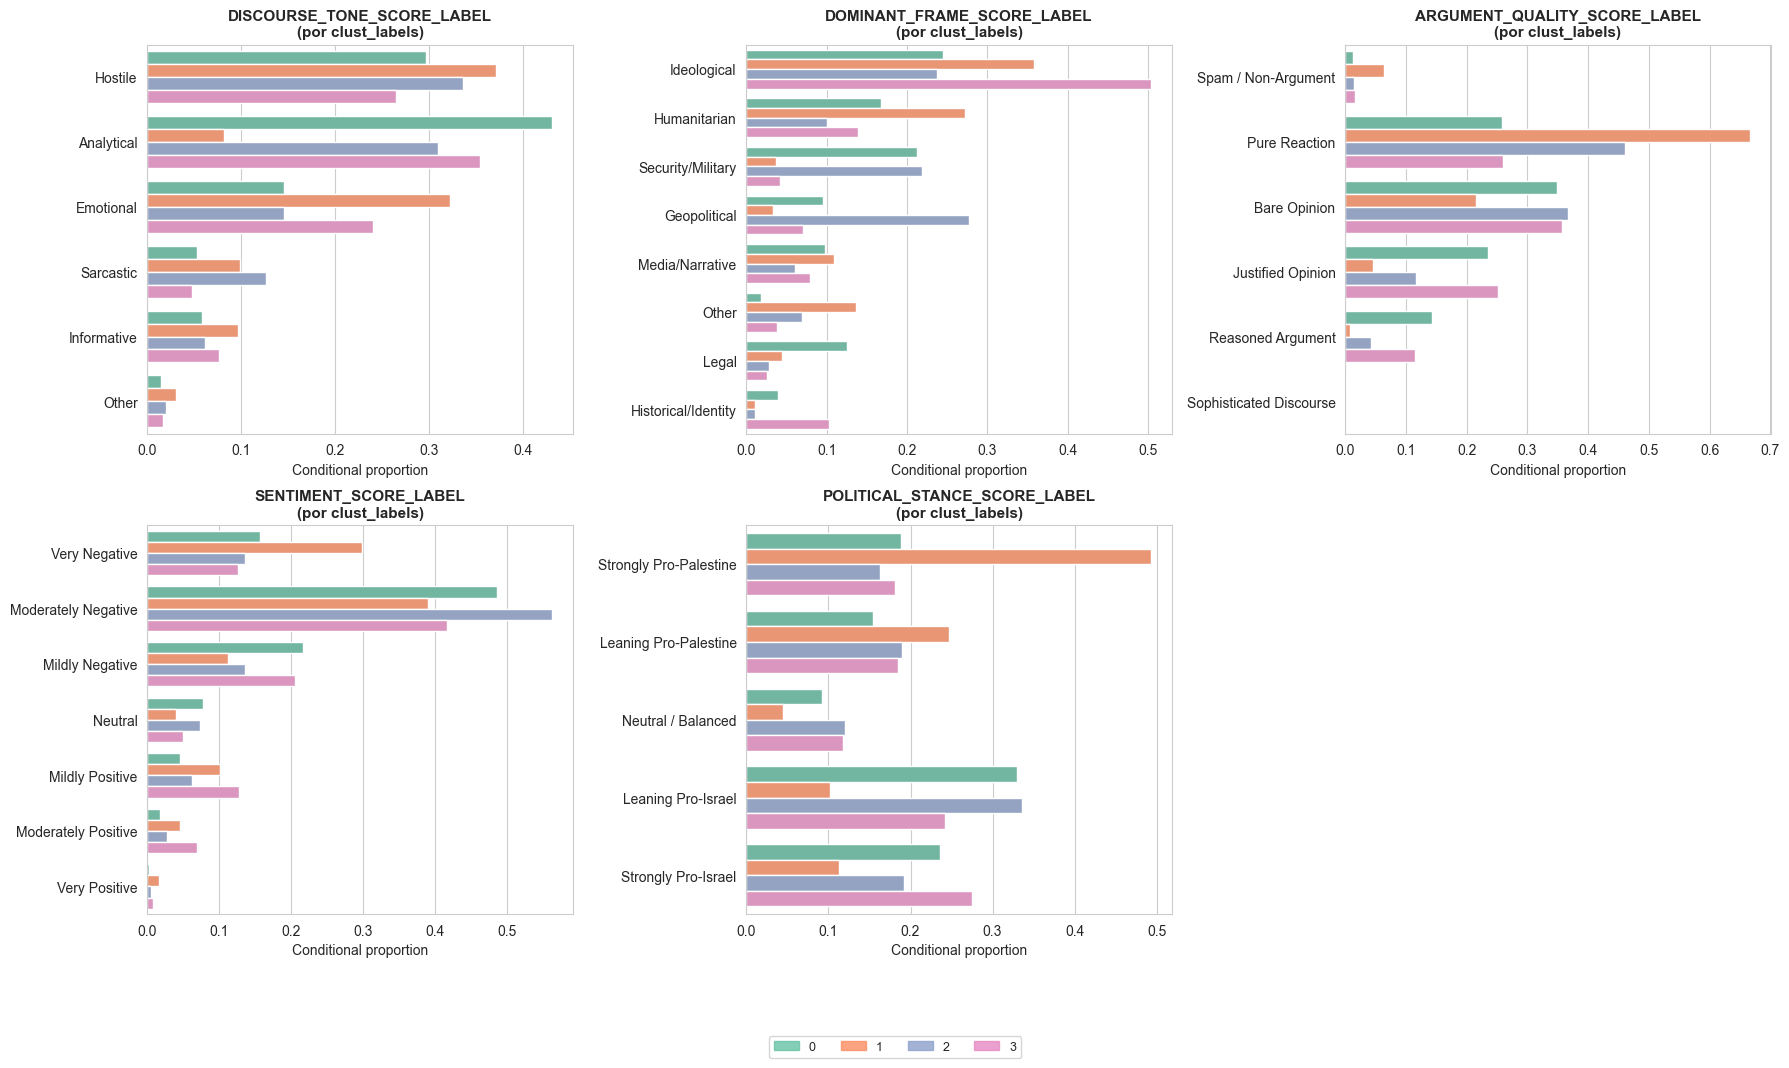

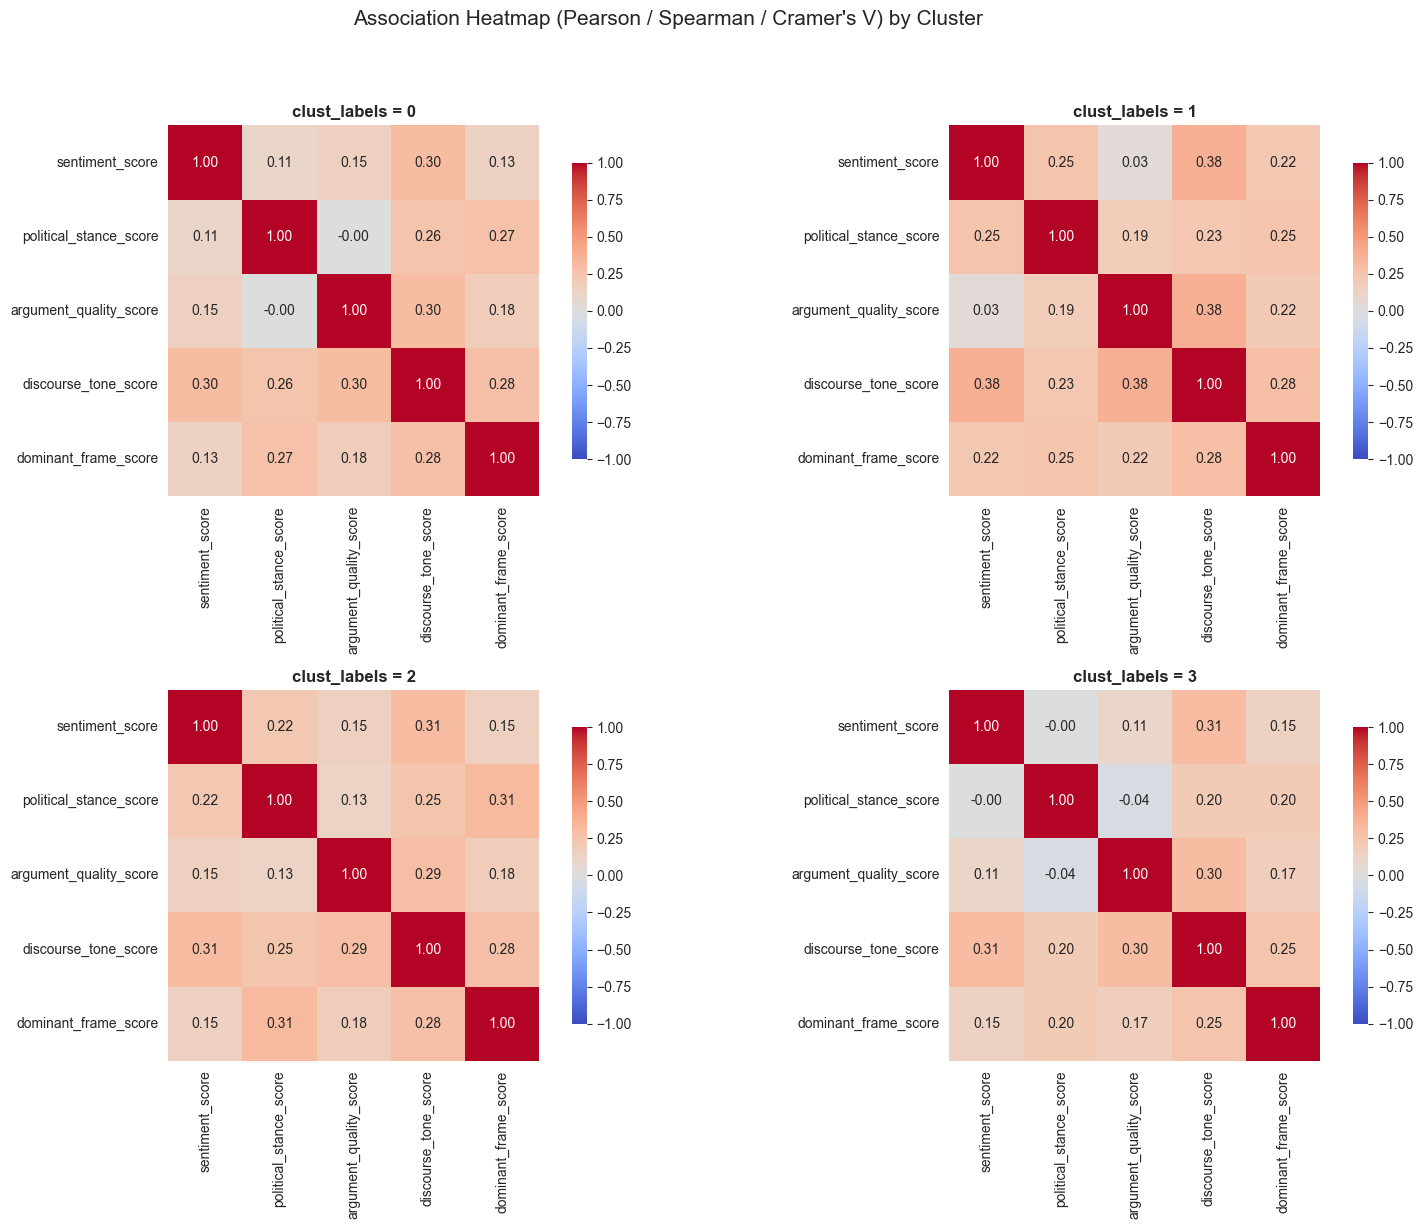

In [7]:
X = processed_data[embeddings_cols_50]

for n_clusters in [4]: # N_CLUSTERS_LIST:

    get_KMeans_results(
        n_clusters, processed_data, X, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
        )

# Time: 10 mins

## Clustering III-b: Data - Embeddings (PCA 90% explained variance)

KMeans - k=4


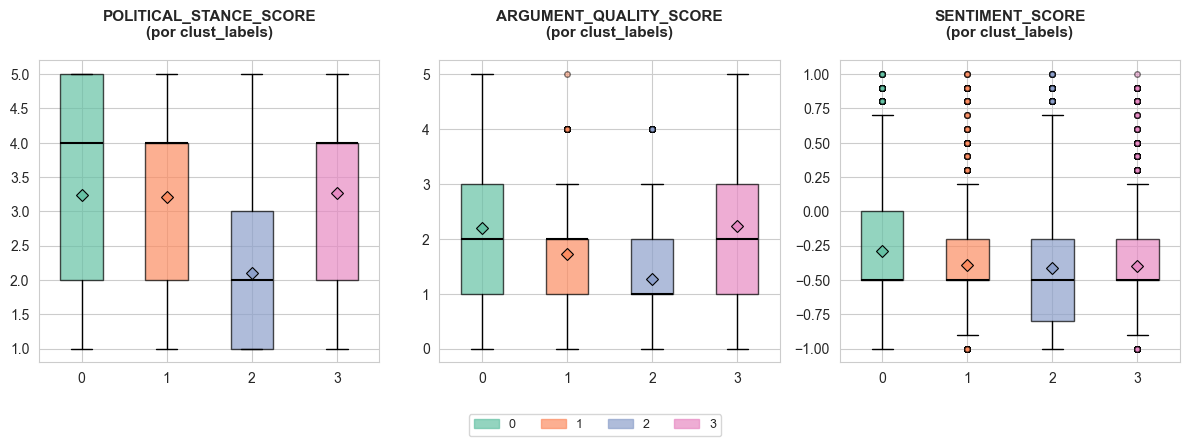

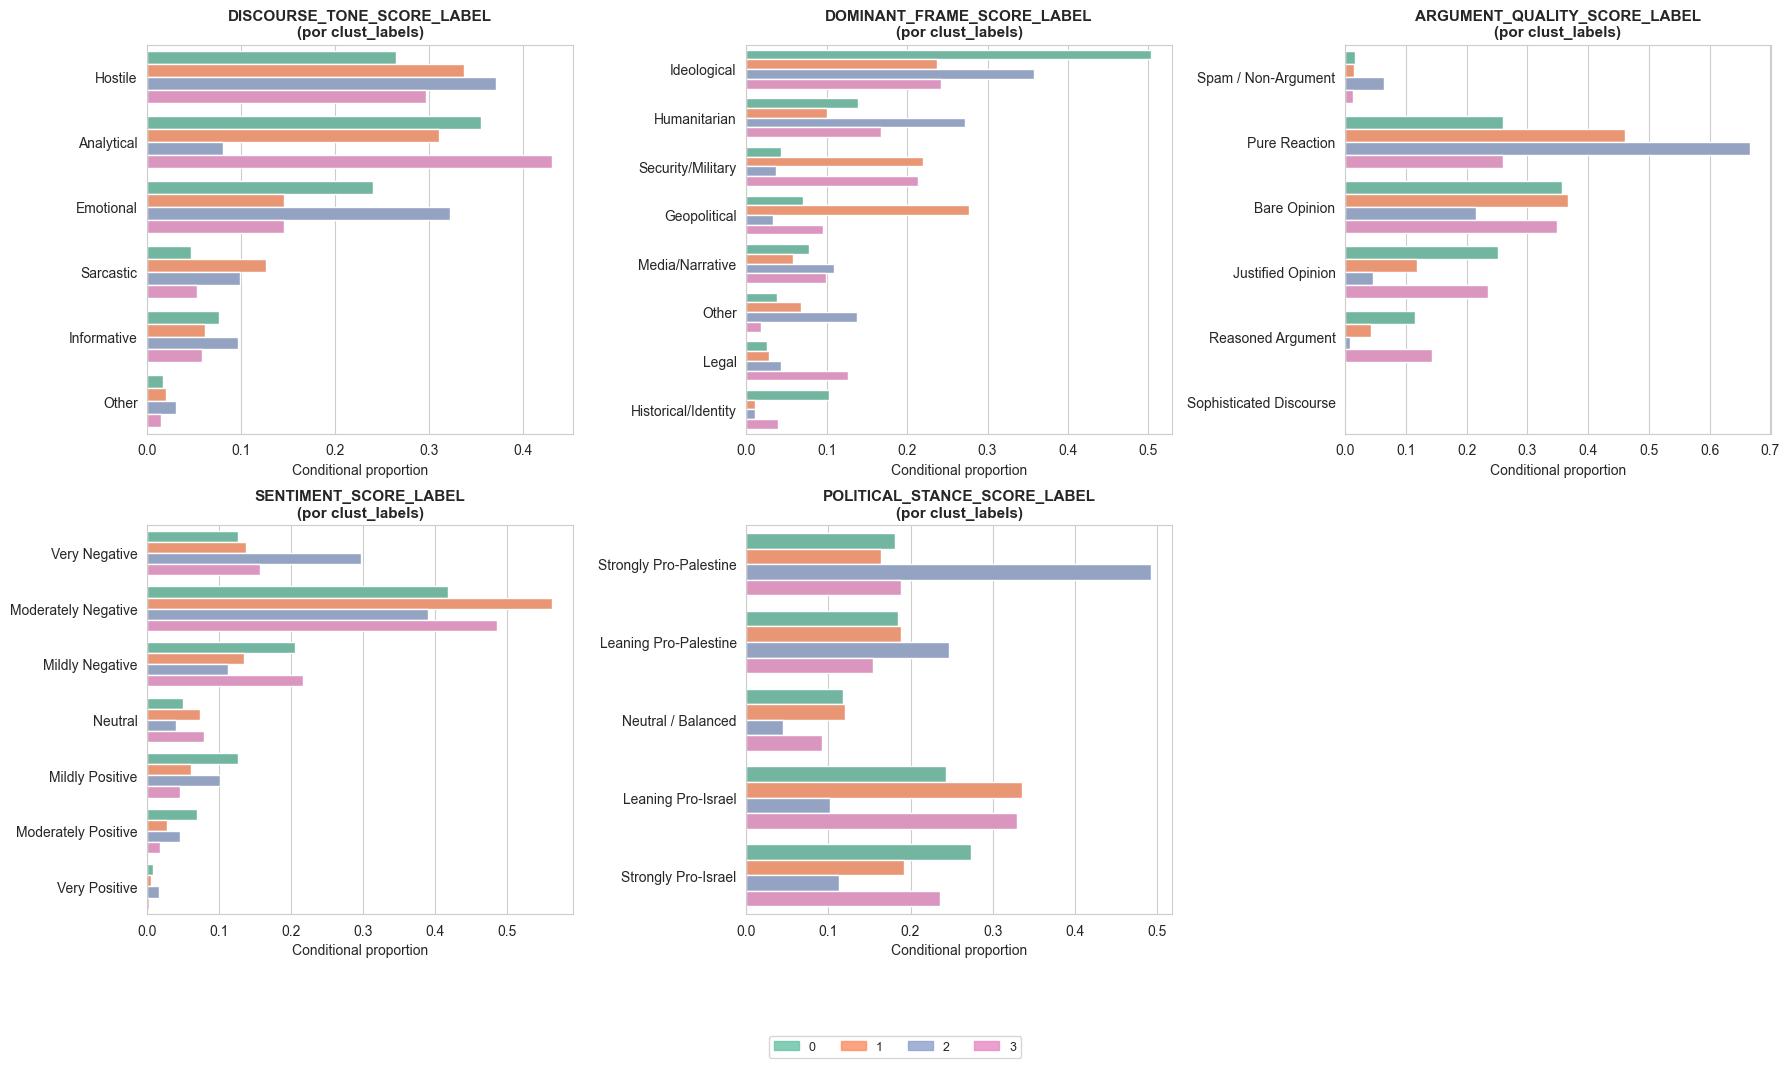

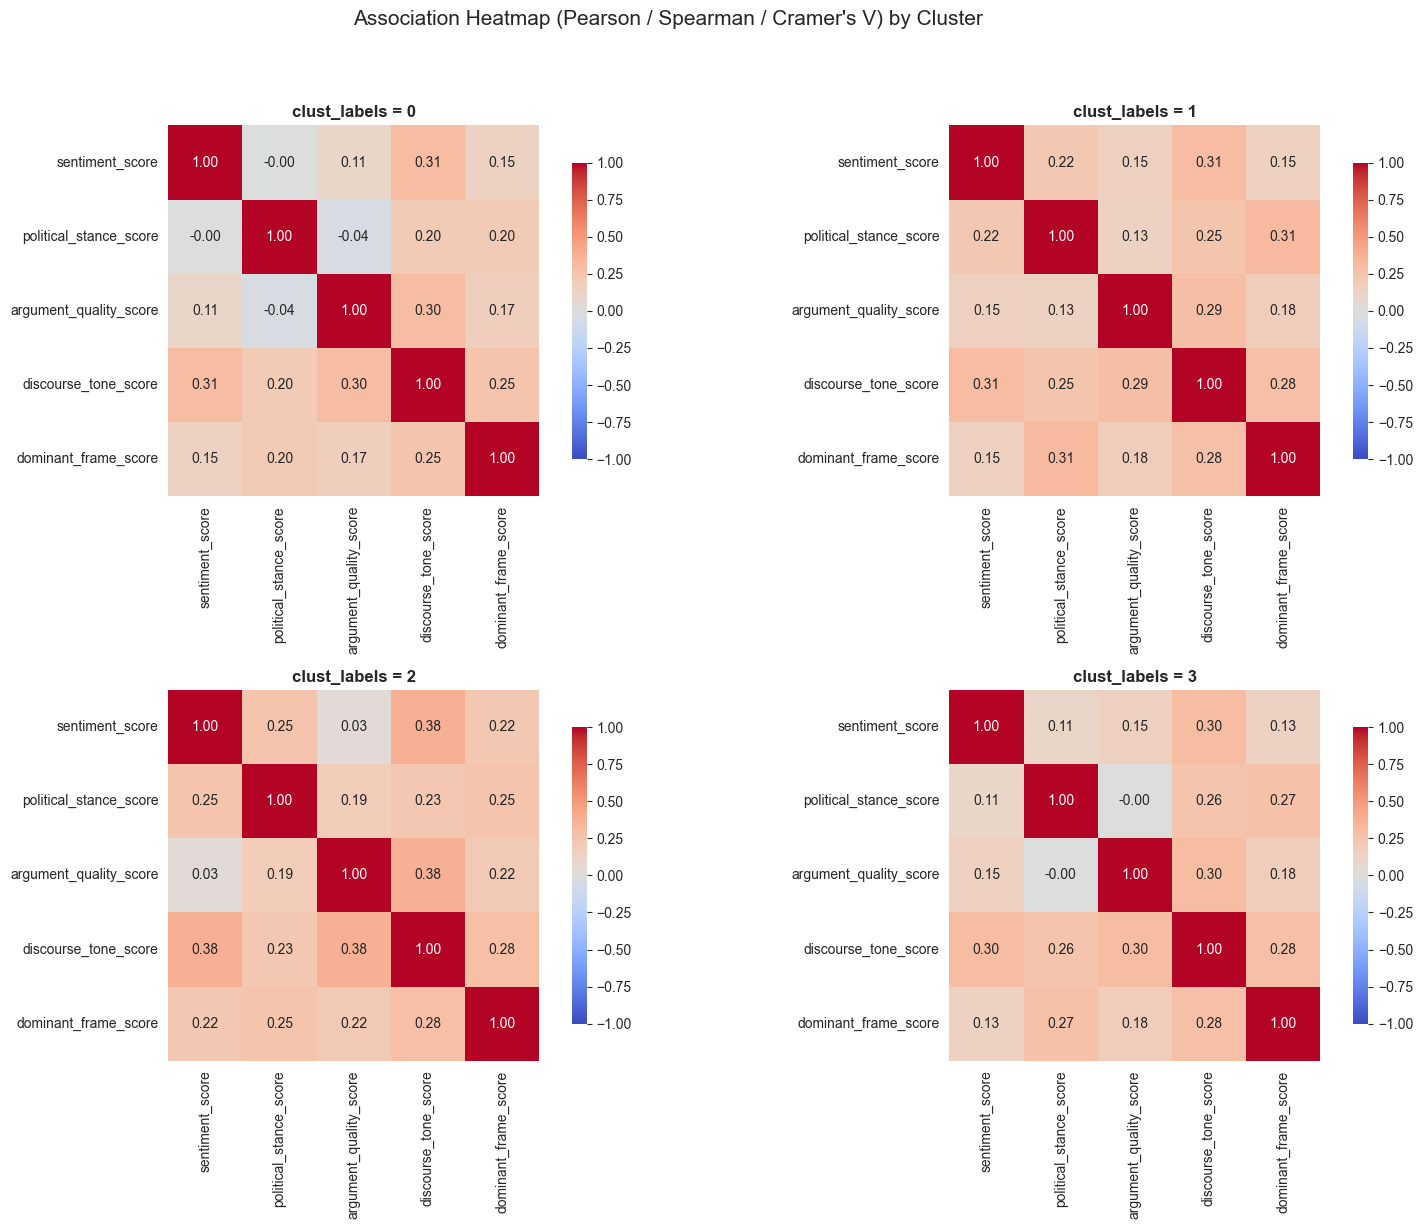

In [8]:
X = processed_data[embeddings_cols_90]

for n_clusters in [4]: # N_CLUSTERS_LIST:

    get_KMeans_results(
        n_clusters, processed_data, X, QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
        )

# Time: 10 mins